<h1>Train — InceptionNet v3</h1>

Trains and evaluates InceptionNet v3 using the tuned hyperparameters from `ARCH_HYPERPARAMS["inception_v3"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Fisantekraal
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1829 | Val: 446 | Test: 252


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["inception_v3"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"InceptionNet v3: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

InceptionNet v3: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with InceptionNet v3)
# ---------------------------------------------------------
model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)

in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

# The auxiliary classifier (used only during training, see run_epoch in
# wwtw_utils.py) also needs its output layer resized to our number of classes.
in_f_aux = model.AuxLogits.fc.in_features
model.AuxLogits.fc = nn.Linear(in_f_aux, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[InceptionNet v3] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[InceptionNet v3] Epoch   1/100 | LR: 1.38e-03 | train loss 1.9000 acc 0.358 | val loss 1.2245 acc 0.410 *


[InceptionNet v3] Epoch   2/100 | LR: 1.38e-03 | train loss 1.4984 acc 0.470 | val loss 1.6083 acc 0.516


[InceptionNet v3] Epoch   3/100 | LR: 1.38e-03 | train loss 1.4486 acc 0.489 | val loss 1.2177 acc 0.464 *


[InceptionNet v3] Epoch   4/100 | LR: 1.38e-03 | train loss 1.3529 acc 0.513 | val loss 1.2079 acc 0.493 *


...

[InceptionNet v3] Epoch  39/100 | LR: 1.38e-04 | train loss 0.3298 acc 0.897 | val loss 0.4581 acc 0.836


[InceptionNet v3] Epoch  40/100 | LR: 1.38e-04 | train loss 0.3242 acc 0.892 | val loss 0.4312 acc 0.836


[InceptionNet v3] Epoch  41/100 | LR: 1.38e-04 | train loss 0.2854 acc 0.908 | val loss 0.4498 acc 0.850


[InceptionNet v3] Epoch  42/100 | LR: 1.38e-04 | train loss 0.2958 acc 0.899 | val loss 0.4404 acc 0.832


[InceptionNet v3] Epoch  43/100 | LR: 1.38e-04 | train loss 0.2984 acc 0.900 | val loss 0.4783 acc 0.839

[InceptionNet v3] No val loss improvement for 10 epochs — stopping early at epoch 43.

[InceptionNet v3] Restored best checkpoint (val loss = 0.4202)


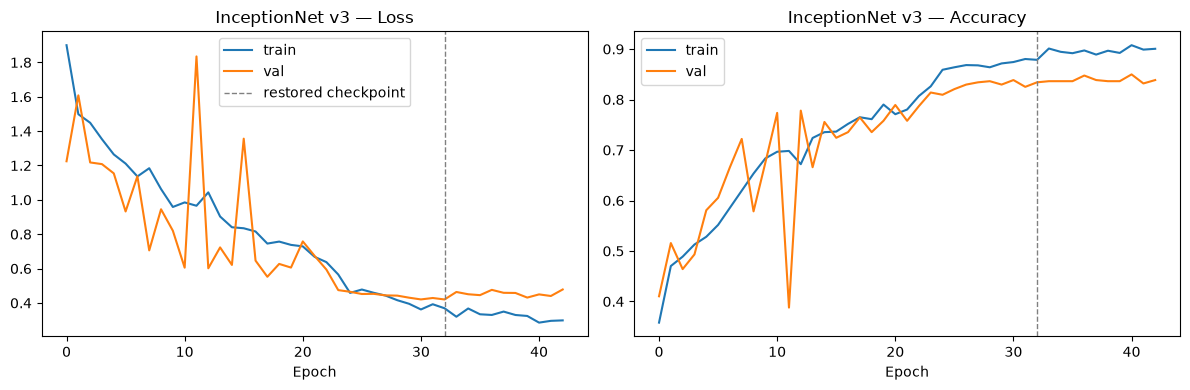

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "InceptionNet v3", is_inception=True,
    accum_steps=accum_steps,
)
plot_training_curves(history, "InceptionNet v3")

## Evaluate on the test set

[InceptionNet v3] Test accuracy: 0.750


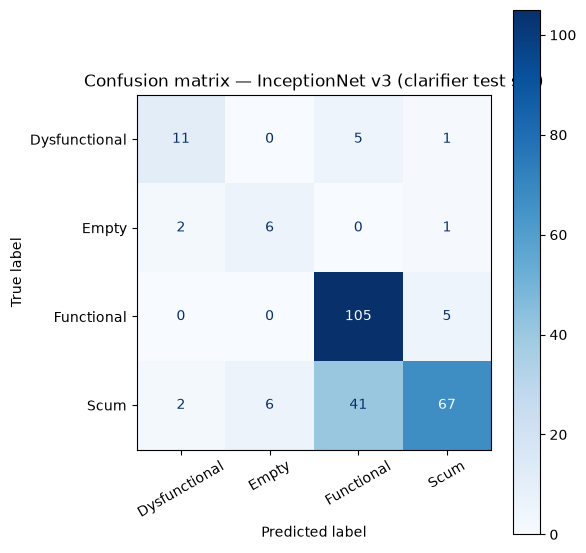

               precision    recall  f1-score   support

Dysfunctional      0.733     0.647     0.688        17
        Empty      0.500     0.667     0.571         9
   Functional      0.695     0.955     0.805       110
         Scum      0.905     0.578     0.705       116

     accuracy                          0.750       252
    macro avg      0.709     0.711     0.692       252
 weighted avg      0.788     0.750     0.743       252



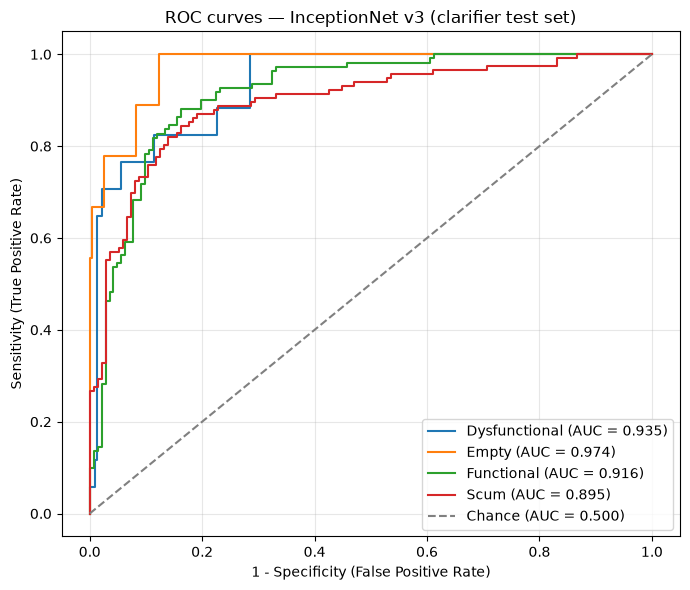

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.935
  Empty          : 0.974
  Functional     : 0.916
  Scum           : 0.895

Mean AUC (over 4/4 classes with test examples): 0.930


(np.float64(0.75),
 {'Dysfunctional': 0.9346683354192741,
  'Empty': 0.9739368998628257,
  'Functional': 0.9159411011523687,
  'Scum': 0.8952205882352942})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "InceptionNet v3", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("InceptionNet v3", "inception_v3")

Saved results to ../results/clarifier_aug/results_clarifier_inception_v3_Fisantekraal.pkl
Saved model weights to ../models/clarifier_inception_v3_cnn.pt
